In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
# Cell 1: imports + load CSV
import pandas as pd
import numpy as np
from pathlib import Path

candidates = [Path("final_model_data.csv"), Path("../final_model_data.csv")]
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("final_model_data.csv not found in current or parent folder.")

df = pd.read_csv(csv_path, low_memory=False)
print(f"Loaded: {csv_path.resolve()} | Shape: {df.shape}")
df.head()


Loaded: /Users/prithabera/data-science-group-project/final_model_data.csv | Shape: (52608, 48)


,datetime,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,...,Temp_Eng_London,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol
0,2020-01-01 00:00:00,26630.5,27418.5,24107.0,1046.5,6465.0,0.0,13040.0,0.0,16.0,...,4.0,0.0,3.5,0.0,4.6,0.0,7.5,0.0,6.2,0.0
1,2020-01-01 01:00:00,26161.5,26837.5,23717.5,1026.5,6465.0,0.0,13040.0,0.0,16.5,...,2.0,0.0,1.3,0.0,4.6,0.0,7.3,0.0,5.4,0.0
2,2020-01-01 02:00:00,24771.5,25683.0,22500.0,993.0,6465.0,0.0,13040.0,0.0,173.5,...,2.0,0.0,1.6,0.0,4.6,0.0,7.3,0.0,4.2,0.0
3,2020-01-01 03:00:00,23382.5,24899.5,21157.0,965.5,6465.0,0.0,13040.0,0.0,843.0,...,2.5,0.0,3.0,0.0,3.6,0.0,7.9,0.0,4.7,0.0
4,2020-01-01 04:00:00,22429.5,23860.0,20393.0,995.5,6465.0,0.0,13040.0,0.0,711.5,...,3.3,0.0,3.7,0.0,3.5,0.0,8.1,0.0,4.9,0.0


In [20]:
# Net demand = ND - embedded wind - embedded solar
df["NET_DEMAND"] = (
    df["ND"]- df["EMBEDDED_WIND_GENERATION"]- df["EMBEDDED_SOLAR_GENERATION"])

# quick check
df[["ND","EMBEDDED_WIND_GENERATION","EMBEDDED_SOLAR_GENERATION","NET_DEMAND"]].head()

,ND,EMBEDDED_WIND_GENERATION,EMBEDDED_SOLAR_GENERATION,NET_DEMAND
0,26630.5,1046.5,0.0,25584.0
1,26161.5,1026.5,0.0,25135.0
2,24771.5,993.0,0.0,23778.5
3,23382.5,965.5,0.0,22417.0
4,22429.5,995.5,0.0,21434.0


In [21]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52608 entries, 0 to 52607
Data columns (total 49 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   datetime                     52608 non-null  object 
 1   ND                           52608 non-null  float64
 2   TSD                          52608 non-null  float64
 3   ENGLAND_WALES_DEMAND         52608 non-null  float64
 4   EMBEDDED_WIND_GENERATION     52608 non-null  float64
 5   EMBEDDED_WIND_CAPACITY       52608 non-null  float64
 6   EMBEDDED_SOLAR_GENERATION    52608 non-null  float64
 7   EMBEDDED_SOLAR_CAPACITY      52608 non-null  float64
 8   NON_BM_STOR                  52608 non-null  float64
 9   PUMP_STORAGE_PUMPING         52608 non-null  float64
 10  NET_IMPORTS                  52608 non-null  float64
 11  SCOTTISH_TRANSFER            52608 non-null  float64
 12  Temp_Scot_Highlands          52608 non-null  float64
 13  Wind10m_Scot_Hig

In [22]:
df.describe()

,ND,TSD,ENGLAND_WALES_DEMAND,EMBEDDED_WIND_GENERATION,EMBEDDED_WIND_CAPACITY,EMBEDDED_SOLAR_GENERATION,EMBEDDED_SOLAR_CAPACITY,NON_BM_STOR,PUMP_STORAGE_PUMPING,NET_IMPORTS,...,Solar_Eng_London,Temp_Eng_South_Kent,Solar_Eng_South_Kent,Temp_Eng_South_Hampshire,Solar_Eng_South_Hampshire,Temp_Eng_South_Cornwall,Solar_Eng_South_Cornwall,Temp_Eng_South_Bristol,Solar_Eng_South_Bristol,NET_DEMAND
count,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.00000,52608.000000,...,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000,52608.000000
mean,26770.351914,28737.705686,24532.497928,1887.057073,6549.762565,1578.623242,15957.783569,0.418596,192.70072,2373.489674,...,129.313850,11.225285,133.449456,11.195497,132.190522,11.505096,134.336698,11.047687,130.382984,23304.671599
std,6204.036984,5919.255561,5679.619570,1212.467655,38.641463,2476.383781,2637.639416,9.629662,358.80173,2797.418146,...,198.246635,5.985446,203.573706,5.858029,202.669453,4.472282,207.144118,5.608837,201.907688,6991.163211
min,12955.000000,15510.500000,12158.000000,126.500000,6465.000000,0.000000,13040.000000,0.000000,0.00000,-7877.500000,...,0.000000,-8.500000,0.000000,-5.200000,0.000000,-4.100000,0.000000,-6.200000,0.000000,-3112.000000
25%,21913.500000,24247.000000,20078.500000,912.000000,6527.000000,0.000000,13724.375000,0.000000,7.00000,713.875000,...,0.000000,7.100000,0.000000,7.200000,0.000000,8.600000,0.000000,7.200000,0.000000,18540.375000
50%,25880.000000,27808.500000,23681.750000,1556.500000,6545.000000,22.500000,15036.750000,0.000000,11.00000,2866.750000,...,6.000000,11.000000,6.000000,11.000000,6.000000,11.400000,6.000000,10.900000,5.000000,22520.750000
75%,30692.625000,32379.750000,28132.625000,2624.500000,6562.000000,2520.625000,17812.375000,0.000000,160.00000,4274.500000,...,203.000000,15.400000,211.000000,15.200000,208.000000,14.700000,207.000000,14.900000,200.000000,27585.500000
max,46419.000000,47654.500000,42327.000000,5941.000000,6622.000000,13951.000000,21504.000000,481.000000,1853.00000,9209.000000,...,881.000000,36.600000,910.000000,33.900000,901.000000,30.400000,923.000000,33.100000,897.000000,45627.500000


In [23]:
df.columns

Index(['datetime', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY',
       'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR',
       'PUMP_STORAGE_PUMPING', 'NET_IMPORTS', 'SCOTTISH_TRANSFER',
       'Temp_Scot_Highlands', 'Wind10m_Scot_Highlands',
       'Temp_Scot_Aberdeenshire', 'Wind10m_Scot_Aberdeenshire',
       'Temp_Scot_Glasgow_West', 'Temp_Scot_Edinburgh_East',
       'Temp_Scot_Borders', 'Wind10m_Scot_Borders', 'Temp_Wales_North_Gwynedd',
       'Wind10m_Wales_North_Gwynedd', 'Temp_Wales_South_Cardiff',
       'Temp_Eng_North_Tyne', 'Temp_Eng_North_Cumbria',
       'Wind10m_Eng_North_Cumbria', 'Temp_Eng_Yorkshire',
       'Wind10m_Eng_Yorkshire', 'Temp_Eng_Manchester',
       'Temp_Eng_West_Midlands', 'Temp_Eng_East_Midlands',
       'Solar_Eng_East_Midlands', 'Temp_Eng_East_Norfolk',
       'Wind10m_Eng_East_Norfolk', 'Solar_Eng_East_Norfolk',
       'Temp_Eng_East_Suffolk', 'Wind10m_Eng_East_Suffolk',
   

In [26]:
def outlier_report_iqr(df, cols=None, k=1.5):
    if cols is None:
        cols = df.select_dtypes(include="number").columns.tolist()

    rows = []
    for c in cols:
        x = df[c].dropna()
        if len(x) < 10:
            continue

        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        if iqr == 0:
            rows.append([c, len(x), 0, 0.0, q1, q3, np.nan, np.nan])
            continue

        lo = q1 - k * iqr
        hi = q3 + k * iqr
        n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
        pct = 100 * n_out / len(df)
        rows.append([c, len(x), n_out, pct, q1, q3, lo, hi])

    rep = pd.DataFrame(
        rows,
        columns=["col", "non_null", "outliers", "outlier_%", "q1", "q3", "lower", "upper"]
    ).sort_values("outliers", ascending=False)

    return rep

report = outlier_report_iqr(df)   # or energy_df / final_model_df
display(report)                 # top 20 columns with most outliers

,col,non_null,outliers,outlier_%,q1,q3,lower,upper
8,PUMP_STORAGE_PUMPING,52608,9829,18.683470,7.000,160.000,-222.5000,389.5000
4,EMBEDDED_WIND_CAPACITY,52608,4906,9.325578,6527.000,6562.000,6474.5000,6614.5000
44,Solar_Eng_South_Cornwall,52608,4460,8.477798,0.000,207.000,-310.5000,517.5000
46,Solar_Eng_South_Bristol,52608,4441,8.441682,0.000,200.000,-300.0000,500.0000
30,Solar_Eng_East_Midlands,52608,4349,8.266804,0.000,187.000,-280.5000,467.5000
33,Solar_Eng_East_Norfolk,52608,4329,8.228786,0.000,199.000,-298.5000,497.5000
38,Solar_Eng_London,52608,4076,7.747871,0.000,203.000,-304.5000,507.5000
36,Solar_Eng_East_Suffolk,52608,4051,7.700350,0.000,212.000,-318.0000,530.0000
40,Solar_Eng_South_Kent,52608,4017,7.635721,0.000,211.000,-316.5000,527.5000
42,Solar_Eng_South_Hampshire,52608,3996,7.595803,0.000,208.000,-312.0000,520.0000


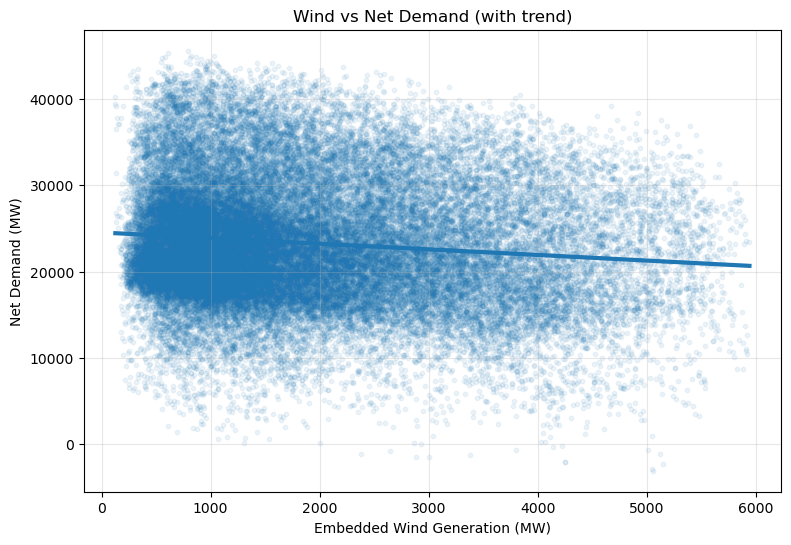

In [45]:

plot_df = df[["EMBEDDED_WIND_GENERATION","NET_DEMAND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(9,6))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_WIND_GENERATION",
    y="NET_DEMAND",
    scatter_kws={"alpha":0.08, "s":10},
    line_kws={"linewidth":3}
)
plt.title("Wind vs Net Demand (with trend)")
plt.xlabel("Embedded Wind Generation (MW)")
plt.ylabel("Net Demand (MW)")
plt.grid(True, alpha=0.3)
plt.show()


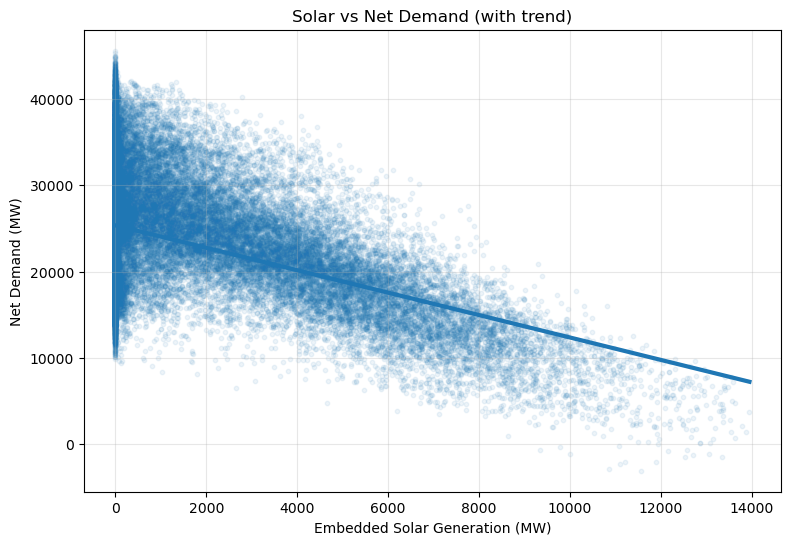

In [46]:
plot_df = df[["EMBEDDED_SOLAR_GENERATION","NET_DEMAND"]].dropna()
#plot_df = plot_df.sample(30000, random_state=42)

plt.figure(figsize=(9,6))
sns.regplot(
    data=plot_df,
    x="EMBEDDED_SOLAR_GENERATION",
    y="NET_DEMAND",
    scatter_kws={"alpha":0.08, "s":10},
    line_kws={"linewidth":3}
)
plt.title("Solar vs Net Demand (with trend)")
plt.xlabel("Embedded Solar Generation (MW)")
plt.ylabel("Net Demand (MW)")
plt.grid(True, alpha=0.3)
plt.show()



/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_2078/2523712186.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["NET_DEMAND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_2078/2523712186.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_nd = tmp.groupby(bins)["NET_DEMAND"].mean()
/var/folders/z_/pzb1cnsj4fq6qjgxkn8w08kh0000gn/T/ipykernel_2078/2523712186.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=Tru

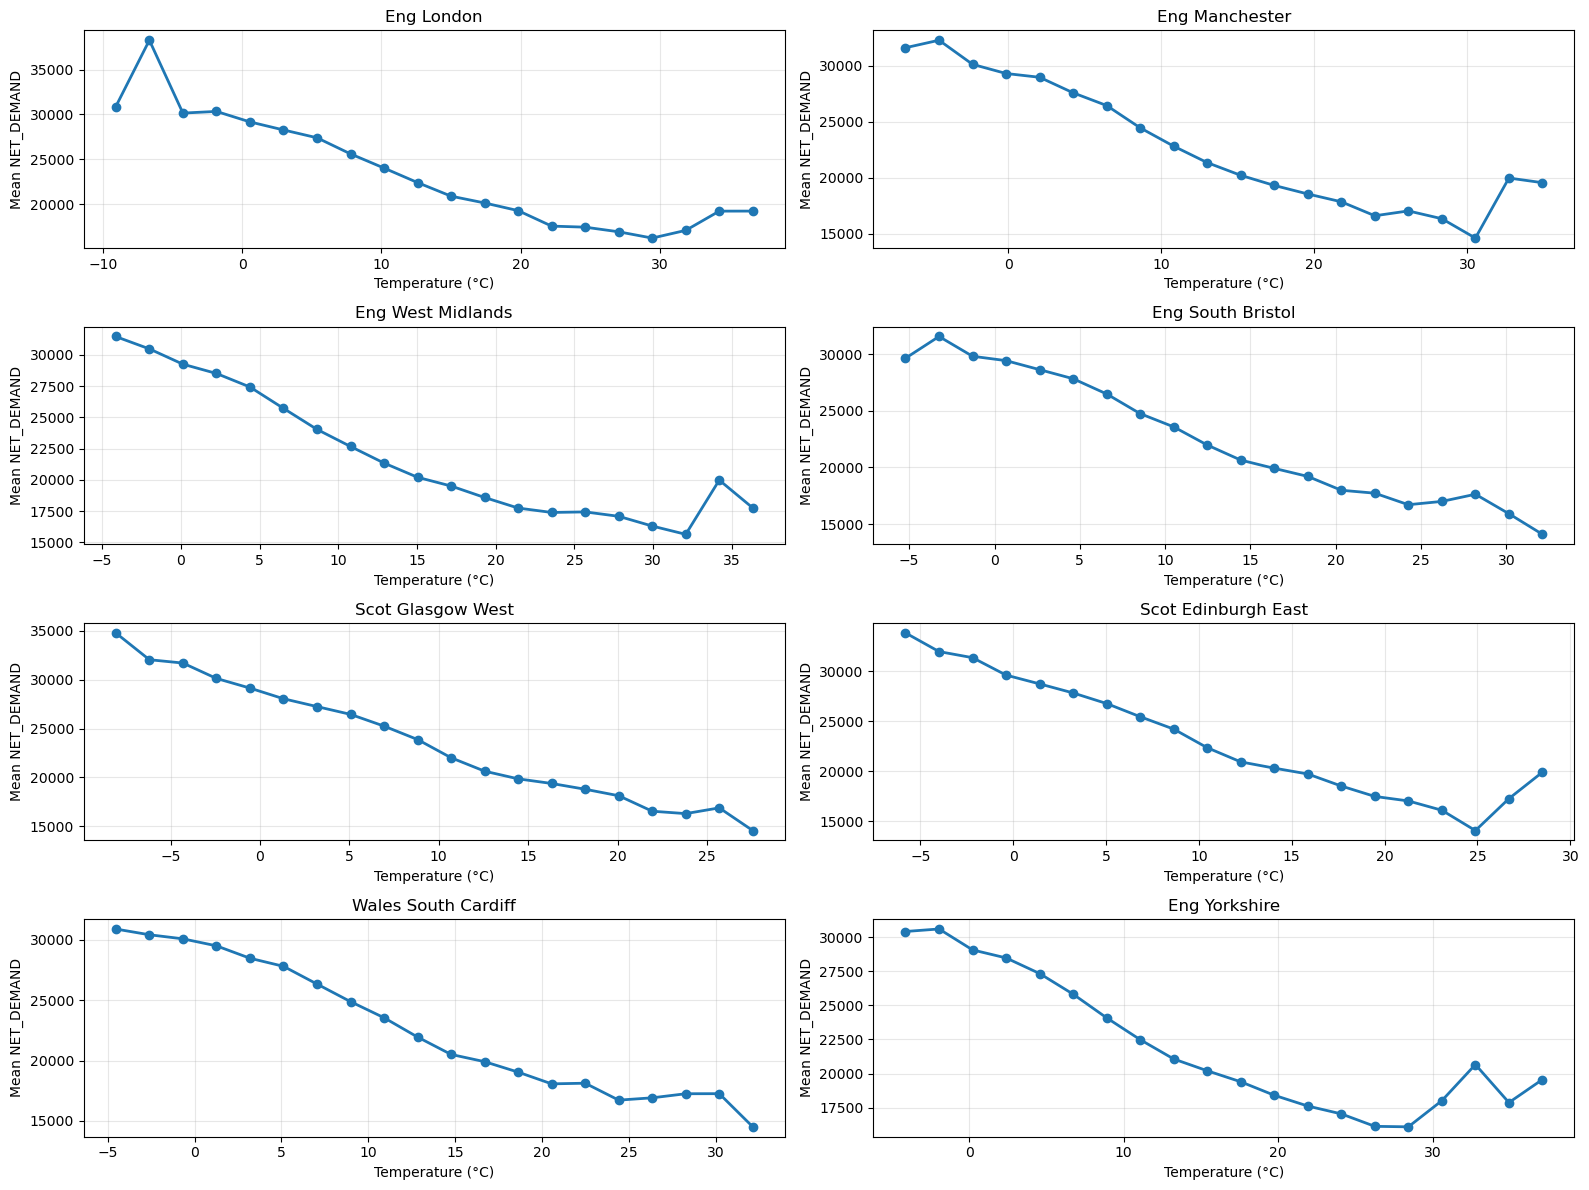

In [35]:


major_temp_cols = [
    "Temp_Eng_London",
    "Temp_Eng_Manchester",
    "Temp_Eng_West_Midlands",
    "Temp_Eng_South_Bristol",
    "Temp_Scot_Glasgow_West",
    "Temp_Scot_Edinburgh_East",
    "Temp_Wales_South_Cardiff",
    "Temp_Eng_Yorkshire"
]

major_temp_cols = [c for c in major_temp_cols if c in df.columns]

plt.figure(figsize=(16, 12))

for i, col in enumerate(major_temp_cols, 1):
    plt.subplot(4, 2, i)

    tmp = df[[col, "NET_DEMAND"]].dropna()

    # bin temperatures (change bins=20 if you want smoother/rougher)
    bins = pd.cut(tmp[col], bins=20)
    mean_nd = tmp.groupby(bins)["NET_DEMAND"].mean()

    # use bin midpoints for x-axis
    x = [b.mid for b in mean_nd.index]

    plt.plot(x, mean_nd.values, marker="o", linewidth=2)
    plt.title(col.replace("Temp_", "").replace("_", " "))
    plt.xlabel("Temperature (°C)")
    plt.ylabel("Mean NET_DEMAND")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Across all major regions, NET_DEMAND increases as temperature decreases, confirming heating-driven demand. The temperature–demand 
# relationship is consistent but varies in strength by region (different slopes), which motivates using regional weather features instead 
# of a single national weather value.

In [ ]:
TARGET = "NET_DEMAND"   # change to "ND" or "TSD" if needed

# 2) Create lag features (48 = yesterday same half-hour, 336 = last week same half-hour)
df[f"{TARGET}_lag_48"]  = df[TARGET].shift(48)
df[f"{TARGET}_lag_336"] = df[TARGET].shift(336)

In [56]:
df[["NET_DEMAND", "NET_DEMAND_lag_48", "NET_DEMAND_lag_336"]].iloc[45:55]


,NET_DEMAND,NET_DEMAND_lag_48,NET_DEMAND_lag_336
45,26960.5,NaN,NaN
46,23750.0,NaN,NaN
47,21320.0,NaN,NaN
48,21047.5,25584.0,NaN
49,21244.0,25135.0,NaN
50,20718.0,23778.5,NaN
51,20225.5,22417.0,NaN
52,19824.0,21434.0,NaN
53,20891.5,21303.5,NaN
54,24454.0,22340.5,NaN


## Why we use Lag-48 and Lag-336

Electricity demand follows strong routines: people wake up, work, cook, and sleep at similar times every day, and weekdays look different from weekends.  
So the demand **at this exact half-hour** is usually close to the demand at the **same half-hour yesterday** and the **same half-hour last week**.

That’s why we add:
- **Lag-48** = demand **24 hours ago** (48 half-hours)
- **Lag-336** = demand **7 days ago** (336 half-hours)

These lag variables act as a strong baseline signal and help models (Linear/Ridge, Random Forest, XGBoost, LSTM) learn the main daily/weekly rhythm, while weather and other features explain the remaining variation (e.g., cold spells, low wind periods, unusual events).


In [59]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "NET_DEMAND"   
H = 48              

# true value we want to predict (tomorrow)
y_true = df[TARGET].shift(-H)
# baseline prediction: tomorrow equals today (same half-hour)
y_pred = df[TARGET]

# remove NaNs created by shifting
mask = y_true.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("BASELINE (Tomorrow = Today)")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))


BASELINE (Tomorrow = Today)
RMSE: 4640.4
MAE : 3511.37
R2  : 0.559


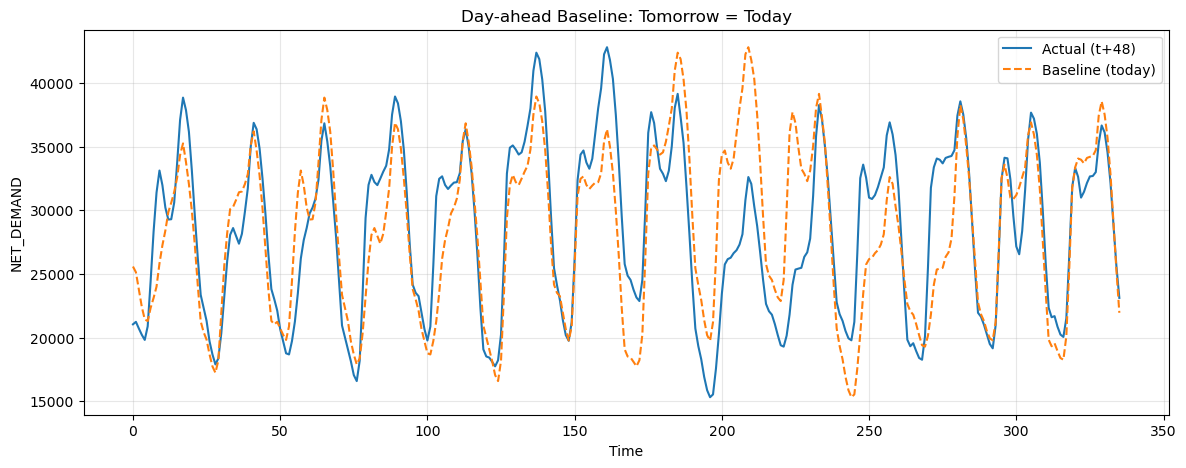

In [60]:
# plot first 7 days (optional)
n = 48 * 7
plt.figure(figsize=(14,5))
plt.plot(y_true.index[:n], y_true.iloc[:n], label="Actual (t+48)")
plt.plot(y_pred.index[:n], y_pred.iloc[:n], label="Baseline (today)", linestyle="--")
plt.title("Day-ahead Baseline: Tomorrow = Today")
plt.xlabel("Time")
plt.ylabel(TARGET)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [61]:
# Baseline 2: “Tomorrow = Same half-hour last week”

TARGET = "NET_DEMAND"   
H = 48
WEEK = 336 
SHIFT = WEEK - H  

# true value we want to predict (tomorrow)
y_true = df[TARGET].shift(-H)
# baseline prediction from last week same half-hour
y_pred = df[TARGET].shift(SHIFT)

# remove NaNs
mask = y_true.notna() & y_pred.notna()
y_true = y_true[mask]
y_pred = y_pred[mask]

# metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("BASELINE (Tomorrow = Last Week Same Time)")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))

BASELINE (Tomorrow = Last Week Same Time)
RMSE: 4763.32
MAE : 3593.81
R2  : 0.535


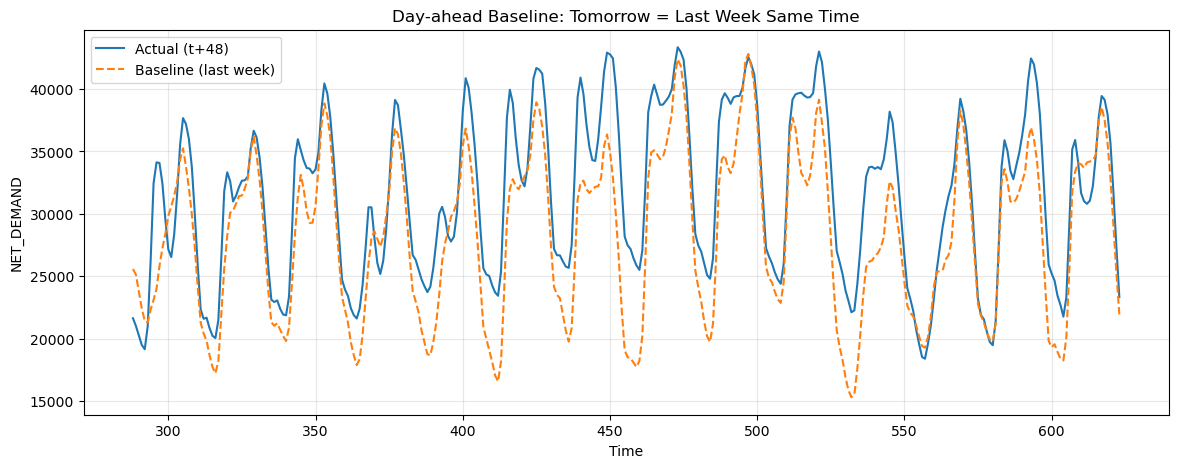

In [62]:
# plot first 7 days (optional)
n = 48 * 7
plt.figure(figsize=(14,5))
plt.plot(y_true.index[:n], y_true.iloc[:n], label="Actual (t+48)")
plt.plot(y_pred.index[:n], y_pred.iloc[:n], label="Baseline (last week)", linestyle="--")
plt.title("Day-ahead Baseline: Tomorrow = Last Week Same Time")
plt.xlabel("Time")
plt.ylabel(TARGET)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [76]:
df.columns

Index(['datetime', 'ND', 'TSD', 'ENGLAND_WALES_DEMAND',
       'EMBEDDED_WIND_GENERATION', 'EMBEDDED_WIND_CAPACITY',
       'EMBEDDED_SOLAR_GENERATION', 'EMBEDDED_SOLAR_CAPACITY', 'NON_BM_STOR',
       'PUMP_STORAGE_PUMPING', 'NET_IMPORTS', 'SCOTTISH_TRANSFER',
       'Temp_Scot_Highlands', 'Wind10m_Scot_Highlands',
       'Temp_Scot_Aberdeenshire', 'Wind10m_Scot_Aberdeenshire',
       'Temp_Scot_Glasgow_West', 'Temp_Scot_Edinburgh_East',
       'Temp_Scot_Borders', 'Wind10m_Scot_Borders', 'Temp_Wales_North_Gwynedd',
       'Wind10m_Wales_North_Gwynedd', 'Temp_Wales_South_Cardiff',
       'Temp_Eng_North_Tyne', 'Temp_Eng_North_Cumbria',
       'Wind10m_Eng_North_Cumbria', 'Temp_Eng_Yorkshire',
       'Wind10m_Eng_Yorkshire', 'Temp_Eng_Manchester',
       'Temp_Eng_West_Midlands', 'Temp_Eng_East_Midlands',
       'Solar_Eng_East_Midlands', 'Temp_Eng_East_Norfolk',
       'Wind10m_Eng_East_Norfolk', 'Solar_Eng_East_Norfolk',
       'Temp_Eng_East_Suffolk', 'Wind10m_Eng_East_Suffolk',
   

In [77]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = df.sort_values("datetime").copy()

TARGET = "NET_DEMAND"

# 1) Always include lags
feature_cols = [f"{TARGET}_lag_48", f"{TARGET}_lag_336"]

# 2) Add ALL regional weather columns automatically
temp_cols  = [c for c in df.columns if c.startswith("Temp_")]
wind_cols  = [c for c in df.columns if c.startswith("Wind10m_")]
solar_cols = [c for c in df.columns if c.startswith("Solar_")]

feature_cols = feature_cols + temp_cols + wind_cols + solar_cols

X_train = train_df[feature_cols]
y_train = train_df[TARGET]

X_test = test_df[feature_cols]
y_test = test_df[TARGET]

print("Train rows:", len(train_df), " Test rows:", len(test_df))
print("Features used:", feature_cols)

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=25,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)
pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("\nRANDOM FOREST RESULTS:")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))


Train rows: 41817  Test rows: 10455
Features used: ['NET_DEMAND_lag_48', 'NET_DEMAND_lag_336', 'Temp_Scot_Highlands', 'Temp_Scot_Aberdeenshire', 'Temp_Scot_Glasgow_West', 'Temp_Scot_Edinburgh_East', 'Temp_Scot_Borders', 'Temp_Wales_North_Gwynedd', 'Temp_Wales_South_Cardiff', 'Temp_Eng_North_Tyne', 'Temp_Eng_North_Cumbria', 'Temp_Eng_Yorkshire', 'Temp_Eng_Manchester', 'Temp_Eng_West_Midlands', 'Temp_Eng_East_Midlands', 'Temp_Eng_East_Norfolk', 'Temp_Eng_East_Suffolk', 'Temp_Eng_London', 'Temp_Eng_South_Kent', 'Temp_Eng_South_Hampshire', 'Temp_Eng_South_Cornwall', 'Temp_Eng_South_Bristol', 'Wind10m_Scot_Highlands', 'Wind10m_Scot_Aberdeenshire', 'Wind10m_Scot_Borders', 'Wind10m_Wales_North_Gwynedd', 'Wind10m_Eng_North_Cumbria', 'Wind10m_Eng_Yorkshire', 'Wind10m_Eng_East_Norfolk', 'Wind10m_Eng_East_Suffolk', 'Solar_Eng_East_Midlands', 'Solar_Eng_East_Norfolk', 'Solar_Eng_East_Suffolk', 'Solar_Eng_London', 'Solar_Eng_South_Kent', 'Solar_Eng_South_Hampshire', 'Solar_Eng_South_Cornwall', 'Sol

In [68]:
# Cell 1: imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [70]:
# Cell 2: feature engineering + split
TARGET = "NET_DEMAND"
H = 48  # 48 half-hours = 1 day ahead

xgb_df = df.copy()

# Create NET_DEMAND if not already present
if TARGET not in xgb_df.columns:
    xgb_df[TARGET] = (
        xgb_df["ND"]
        - xgb_df["EMBEDDED_WIND_GENERATION"]
        - xgb_df["EMBEDDED_SOLAR_GENERATION"]
    )

# Time features
xgb_df["datetime"] = pd.to_datetime(xgb_df["datetime"], errors="coerce")
xgb_df = xgb_df.sort_values("datetime").reset_index(drop=True)

xgb_df["hour"] = xgb_df["datetime"].dt.hour
xgb_df["minute"] = xgb_df["datetime"].dt.minute
xgb_df["dayofweek"] = xgb_df["datetime"].dt.dayofweek
xgb_df["month"] = xgb_df["datetime"].dt.month
xgb_df["is_weekend"] = (xgb_df["dayofweek"] >= 5).astype(int)

# Lag + rolling features
for lag in [1, 2, 48, 96, 336]:
    xgb_df[f"{TARGET}_lag_{lag}"] = xgb_df[TARGET].shift(lag)

xgb_df[f"{TARGET}_roll_mean_48"] = xgb_df[TARGET].shift(1).rolling(48).mean()
xgb_df[f"{TARGET}_roll_std_48"] = xgb_df[TARGET].shift(1).rolling(48).std()

# Future target
xgb_df["target_t_plus_48"] = xgb_df[TARGET].shift(-H)

# Numeric features only
feature_cols = [
    c for c in xgb_df.columns
    if c not in ["datetime", "target_t_plus_48"]
    and pd.api.types.is_numeric_dtype(xgb_df[c])
]

model_df = xgb_df[["datetime", "target_t_plus_48"] + feature_cols].dropna().copy()

# Time-based split: 70% train, 15% val, 15% test
n = len(model_df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = model_df.iloc[:train_end]
val_df = model_df.iloc[train_end:val_end]
test_df = model_df.iloc[val_end:]

X_train, y_train = train_df[feature_cols], train_df["target_t_plus_48"]
X_val, y_val = val_df[feature_cols], val_df["target_t_plus_48"]
X_test, y_test = test_df[feature_cols], test_df["target_t_plus_48"]

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Features:", len(feature_cols))


Train: (36556, 60) Val: (7834, 60) Test: (7834, 60)
Features: 60


In [71]:
# Cell 3: train XGBoost
xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    min_child_weight=3,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=100
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=200
)


[0]	validation_0-rmse:6643.16932	validation_1-rmse:6986.90892
[200]	validation_0-rmse:1667.97341	validation_1-rmse:3369.10246
[269]	validation_0-rmse:1481.52011	validation_1-rmse:3375.75526


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.85, device=None, early_stopping_rounds=100,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=3000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [72]:
# Cell 4: evaluate
y_pred = xgb_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("XGBoost (Day-ahead, t+48)")
print("Best iteration:", xgb_model.best_iteration)
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 4))


XGBoost (Day-ahead, t+48)
Best iteration: 169
RMSE: 3780.66
MAE : 2738.59
R2  : 0.7296


,importance
NET_DEMAND,0.374725
NET_DEMAND_lag_96,0.230846
is_weekend,0.043264
ENGLAND_WALES_DEMAND,0.030825
NET_DEMAND_lag_48,0.026620
NET_DEMAND_lag_1,0.026237
dayofweek,0.025172
ND,0.019632
Solar_Eng_South_Cornwall,0.012902
hour,0.012839


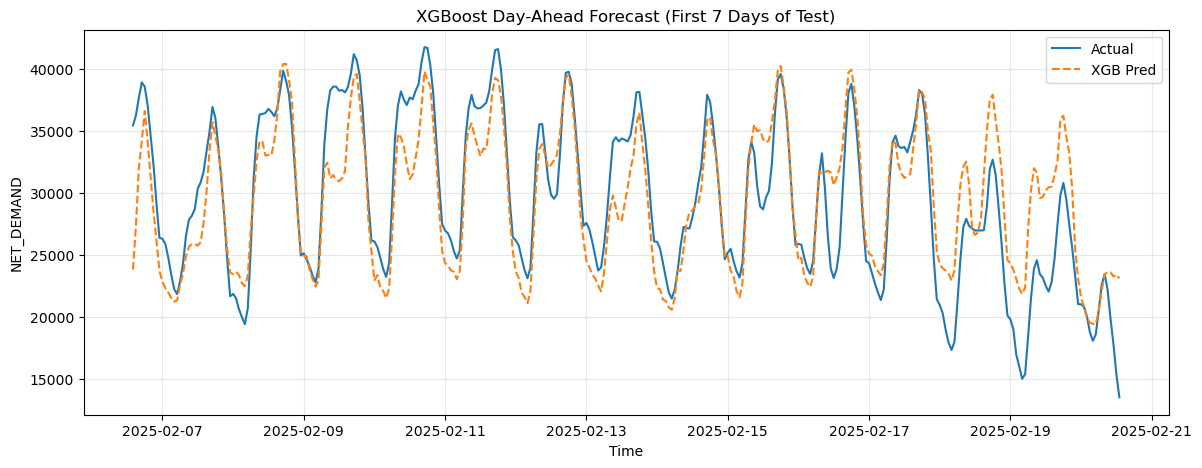

In [73]:
# Cell 5: feature importance + plot + save predictions
imp = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
display(imp.head(20).to_frame("importance"))

pred_df = pd.DataFrame({
    "datetime": test_df["datetime"].values,
    "actual": y_test.values,
    "xgb_pred": y_pred
})
pred_df.to_csv("xgb_day_ahead_predictions.csv", index=False)

n_plot = 48 * 7
plt.figure(figsize=(14, 5))
plt.plot(pred_df["datetime"].iloc[:n_plot], pred_df["actual"].iloc[:n_plot], label="Actual")
plt.plot(pred_df["datetime"].iloc[:n_plot], pred_df["xgb_pred"].iloc[:n_plot], "--", label="XGB Pred")
plt.title("XGBoost Day-Ahead Forecast (First 7 Days of Test)")
plt.xlabel("Time")
plt.ylabel(TARGET)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [75]:
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = df.sort_values("datetime").copy()

TARGET = "NET_DEMAND"

# lag features
df[f"{TARGET}_lag_48"]  = df[TARGET].shift(48)
df[f"{TARGET}_lag_336"] = df[TARGET].shift(336)

df_model = df.dropna(subset=[f"{TARGET}_lag_48", f"{TARGET}_lag_336"]).copy()

# 80/20 time split (no shuffle)
split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx]
test_df  = df_model.iloc[split_idx:]

feature_cols = [
    f"{TARGET}_lag_48",
    f"{TARGET}_lag_336",
    "EMBEDDED_WIND_GENERATION",
    "EMBEDDED_SOLAR_GENERATION",
]
feature_cols = [c for c in feature_cols if c in df_model.columns]

X_train = train_df[feature_cols]
y_train = train_df[TARGET]
X_test  = test_df[feature_cols]
y_test  = test_df[TARGET]

print("Train rows:", len(train_df), " Test rows:", len(test_df))
print("Features used:", feature_cols)

# ✅ early_stopping_rounds goes HERE
model = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    n_jobs=-1,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=50
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=200
)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae  = mean_absolute_error(y_test, pred)
r2   = r2_score(y_test, pred)

print("\nXGBOOST RESULTS:")
print("RMSE:", round(rmse, 2))
print("MAE :", round(mae, 2))
print("R2  :", round(r2, 3))

Train rows: 41817  Test rows: 10455
Features used: ['NET_DEMAND_lag_48', 'NET_DEMAND_lag_336', 'EMBEDDED_WIND_GENERATION', 'EMBEDDED_SOLAR_GENERATION']
[0]	validation_0-rmse:7597.52662
[197]	validation_0-rmse:2928.84634

XGBOOST RESULTS:
RMSE: 2925.71
MAE : 2217.83
R2  : 0.858
